In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data=pd.read_csv('/content/Tesla - Deaths.csv')
data

,Case #,Year,Date,Country,State,Description,Deaths,Tesla driver,Tesla occupant,Other vehicle,...,Verified Tesla Autopilot Deaths,Verified Tesla Autopilot Deaths + All Deaths Reported to NHTSA SGO,Unnamed: 16,Unnamed: 17,Source,Note,Deceased 1,Deceased 2,Deceased 3,Deceased 4
0,294.0,2022.0,1/17/2023,USA,CA,Tesla crashes into back of semi,1.0,1,-,-,...,-,-,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20230118162813/ht...,NaN,NaN,NaN,NaN,NaN
1,293.0,2022.0,1/7/2023,Canada,-,Tesla crashes,1.0,1,-,-,...,-,-,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20230109041434/ht...,NaN,Taren Singh Lal,NaN,NaN,NaN
2,292.0,2022.0,1/7/2023,USA,WA,"Tesla hits pole, catches on fire",1.0,-,1,-,...,-,-,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20230107232745/ht...,NaN,NaN,NaN,NaN,NaN
3,291.0,2022.0,12/22/2022,USA,GA,Tesla crashes and burns,1.0,1,-,-,...,-,-,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20221222203930/ht...,NaN,NaN,NaN,NaN,NaN
4,290.0,2022.0,12/19/2022,Canada,-,Tesla crashes into storefront,1.0,-,-,-,...,-,-,https://web.archive.org/web/20221223203725/ht...,https://web.archive.org/web/20221223203725/ht...,https://web.archive.org/web/20221223203725/ht...,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
302,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
303,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
304,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
305,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307 entries, 0 to 306
Data columns (total 24 columns):
 #   Column                                                                Non-Null Count  Dtype  
---  ------                                                                --------------  -----  
 0   Case #                                                                294 non-null    float64
 1   Year                                                                  294 non-null    float64
 2   Date                                                                  294 non-null    object 
 3    Country                                                              294 non-null    object 
 4    State                                                                294 non-null    object 
 5    Description                                                          295 non-null    object 
 6    Deaths                                                               299 non-null    float64
 7  

In [7]:
data.isnull().sum()

,0
Case #,13
Year,13
Date,13
Country,13
State,13
Description,12
Deaths,8
Tesla driver,13
Tesla occupant,17
Other vehicle,12


Remove any columns which might not be relevant for the analysis.

Unnamed: 16 & Unnamed: 17 contain web link which is not useful
Source : contains web link
Note : contains additional info
Deceased 1 2 3 and 4 contain name of the deceased which is irrelevant to the analysis.
Case # not required
Year can be derived from date

In [8]:
drop_columns = ['Case #','Year', 'Unnamed: 16', 'Unnamed: 17', ' Source ', ' Note ', ' Deceased 1 ',
       ' Deceased 2 ', ' Deceased 3 ', ' Deceased 4 ']
data.drop(columns = drop_columns, inplace = True)

In [9]:
data.shape

(307, 14)

In [10]:
data.columns

Index(['Date', ' Country ', ' State ', ' Description ', ' Deaths ',
       ' Tesla driver ', ' Tesla occupant ', ' Other vehicle ',
       ' Cyclists/ Peds ', ' TSLA+cycl / peds ', ' Model ',
       ' Autopilot claimed ', ' Verified Tesla Autopilot Deaths ',
       ' Verified Tesla Autopilot Deaths + All Deaths Reported to NHTSA SGO '],
      dtype='object')

In [11]:
data[' Verified Tesla Autopilot Deaths + All Deaths Reported to NHTSA SGO '].value_counts(dropna = False)

,count
Verified Tesla Autopilot Deaths + All Deaths Reported to NHTSA SGO,
-,269
1,21
NaN,11
2,3
3,1
24,1
27,1


In [12]:
data.drop(columns = ' Verified Tesla Autopilot Deaths + All Deaths Reported to NHTSA SGO ', inplace = True)

In [13]:
data.shape

(307, 13)

For numerical columns replace "-" with 0 and others with their respective numbers

---



In [14]:
cols = data.columns[5:]
for col in cols:
  if col != ' Model ':
    print(col)
    data[col] = data[col].fillna("-")
    data[col] = data[col].str.strip()
    data[col] = data[col].replace("-", "0")
    data[col] = data[col].astype(int)
    #print(data[col].unique())

 Tesla driver 
 Tesla occupant 
 Other vehicle 
 Cyclists/ Peds 
 TSLA+cycl / peds 
 Autopilot claimed 
 Verified Tesla Autopilot Deaths 


In [15]:
data.head()

,Date,Country,State,Description,Deaths,Tesla driver,Tesla occupant,Other vehicle,Cyclists/ Peds,TSLA+cycl / peds,Model,Autopilot claimed,Verified Tesla Autopilot Deaths
0,1/17/2023,USA,CA,Tesla crashes into back of semi,1.0,1,0,0,0,1,-,0,0
1,1/7/2023,Canada,-,Tesla crashes,1.0,1,0,0,0,1,-,0,0
2,1/7/2023,USA,WA,"Tesla hits pole, catches on fire",1.0,0,1,0,0,1,-,0,0
3,12/22/2022,USA,GA,Tesla crashes and burns,1.0,1,0,0,0,1,-,0,0
4,12/19/2022,Canada,-,Tesla crashes into storefront,1.0,0,0,0,1,1,-,0,0


In [16]:
data.isna().sum()

,0
Date,13
Country,13
State,13
Description,12
Deaths,8
Tesla driver,0
Tesla occupant,0
Other vehicle,0
Cyclists/ Peds,0
TSLA+cycl / peds,0


In [17]:
data.dropna(inplace=True)

In [18]:
data.shape

(294, 13)

In [19]:
data.isna().sum()

,0
Date,0
Country,0
State,0
Description,0
Deaths,0
Tesla driver,0
Tesla occupant,0
Other vehicle,0
Cyclists/ Peds,0
TSLA+cycl / peds,0


In [20]:
data.columns

Index(['Date', ' Country ', ' State ', ' Description ', ' Deaths ',
       ' Tesla driver ', ' Tesla occupant ', ' Other vehicle ',
       ' Cyclists/ Peds ', ' TSLA+cycl / peds ', ' Model ',
       ' Autopilot claimed ', ' Verified Tesla Autopilot Deaths '],
      dtype='object')

Change the variable names in accordance to the python norms

In [21]:
data.columns = data.columns.str.strip()
data.columns

Index(['Date', 'Country', 'State', 'Description', 'Deaths', 'Tesla driver',
       'Tesla occupant', 'Other vehicle', 'Cyclists/ Peds', 'TSLA+cycl / peds',
       'Model', 'Autopilot claimed', 'Verified Tesla Autopilot Deaths'],
      dtype='object')

In [26]:
data.columns = data.columns.str.replace(" ", "").str.replace("+","_")

In [28]:
data.columns = data.columns.str.replace(" ", "").str.replace("/","_")

In [29]:
data.columns

Index(['Date', 'Country', 'State', 'Description', 'Deaths', 'Tesla_Driver',
       'Tesla_Occupant', 'Other_Vehicle', 'Cyclists_Peds', 'TSLA_cycl_peds',
       'Model', 'Claimed', 'VTAD'],
      dtype='object')

In [30]:
data.rename(columns = {"Autopilotclaimed":"Claimed", "VerifiedTeslaAutopilotDeaths":"VTAD",
                       "Teslaoccupant" : "Tesla_Occupant", "Othervehicle":'Other_Vehicle',
                       "Tesladriver": "Tesla_Driver"}, inplace = True)

In [31]:
data.columns

Index(['Date', 'Country', 'State', 'Description', 'Deaths', 'Tesla_Driver',
       'Tesla_Occupant', 'Other_Vehicle', 'Cyclists_Peds', 'TSLA_cycl_peds',
       'Model', 'Claimed', 'VTAD'],
      dtype='object')

Exploratory Data Analysis

Perform an in depth exploratory data analysis. Analysing the number of events by date, per year , per day for each state and country.

In [32]:
data['Date']=pd.to_datetime(data['Date'])

In [35]:
data.loc[:,"event_year"] = data.Date.dt.year
data.loc[:,"event_month"] = data.Date.dt.month
data.loc[:,"event_day"] = data.Date.dt.day

In [37]:
data.columns

Index(['Date', 'Country', 'State', 'Description', 'Deaths', 'Tesla_Driver',
       'Tesla_Occupant', 'Other_Vehicle', 'Cyclists_Peds', 'TSLA_cycl_peds',
       'Model', 'Claimed', 'VTAD', 'event_year', 'event_month', 'event_day'],
      dtype='object')

In [38]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 294 entries, 0 to 293
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            294 non-null    datetime64[ns]
 1   Country         294 non-null    object        
 2   State           294 non-null    object        
 3   Description     294 non-null    object        
 4   Deaths          294 non-null    float64       
 5   Tesla_Driver    294 non-null    int64         
 6   Tesla_Occupant  294 non-null    int64         
 7   Other_Vehicle   294 non-null    int64         
 8   Cyclists_Peds   294 non-null    int64         
 9   TSLA_cycl_peds  294 non-null    int64         
 10  Model           294 non-null    object        
 11  Claimed         294 non-null    int64         
 12  VTAD            294 non-null    int64         
 13  event_year      294 non-null    int32         
 14  event_month     294 non-null    int32         
 15  event_day  

In [39]:
data.head()

,Date,Country,State,Description,Deaths,Tesla_Driver,Tesla_Occupant,Other_Vehicle,Cyclists_Peds,TSLA_cycl_peds,Model,Claimed,VTAD,event_year,event_month,event_day
0,2023-01-17,USA,CA,Tesla crashes into back of semi,1.0,1,0,0,0,1,-,0,0,2023,1,17
1,2023-01-07,Canada,-,Tesla crashes,1.0,1,0,0,0,1,-,0,0,2023,1,7
2,2023-01-07,USA,WA,"Tesla hits pole, catches on fire",1.0,0,1,0,0,1,-,0,0,2023,1,7
3,2022-12-22,USA,GA,Tesla crashes and burns,1.0,1,0,0,0,1,-,0,0,2022,12,22
4,2022-12-19,Canada,-,Tesla crashes into storefront,1.0,0,0,0,1,1,-,0,0,2022,12,19


In [40]:
data['event_year'].unique()

array([2023, 2022, 2021, 2020, 2019, 2018, 2017, 2016, 2015, 2014, 2013],
      dtype=int32)

In [41]:
data['event_year'].value_counts()

,count
event_year,
2022,93
2021,58
2019,46
2020,39
2018,18
2016,15
2017,11
2015,5
2014,4


In [42]:
data = data[data.event_year!= 2023]

In [43]:
data['event_year'].value_counts()

,count
event_year,
2022,93
2021,58
2019,46
2020,39
2018,18
2016,15
2017,11
2015,5
2014,4


In [45]:
vc = data.event_year.value_counts()
vc = vc.sort_index()
vc

,count
event_year,
2013,2
2014,4
2015,5
2016,15
2017,11
2018,18
2019,46
2020,39
2021,58


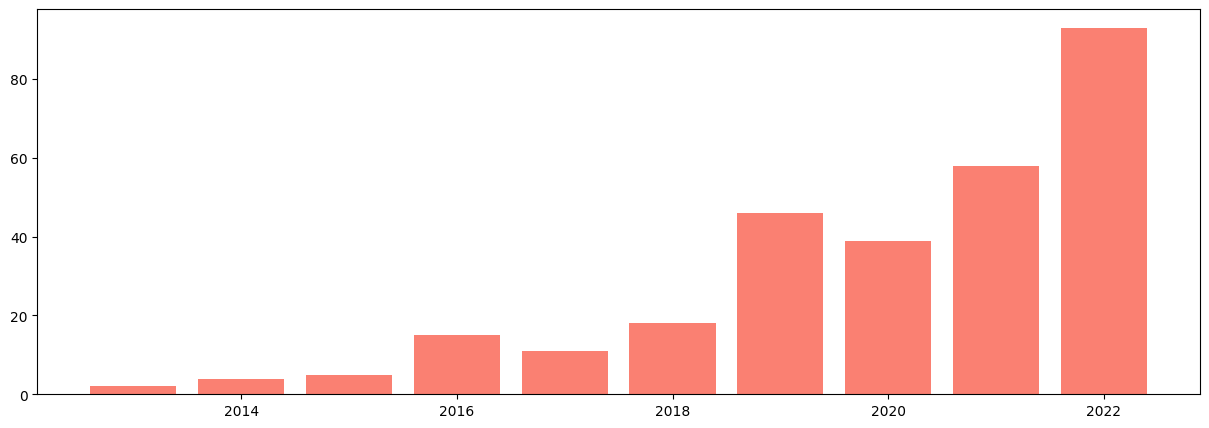

In [46]:
plt.figure(figsize = (15,5))
plt.bar(x=vc.index,height=vc.values,color='salmon')
plt.show()

In [47]:
# month wise

In [48]:
vc=data.event_month.value_counts()

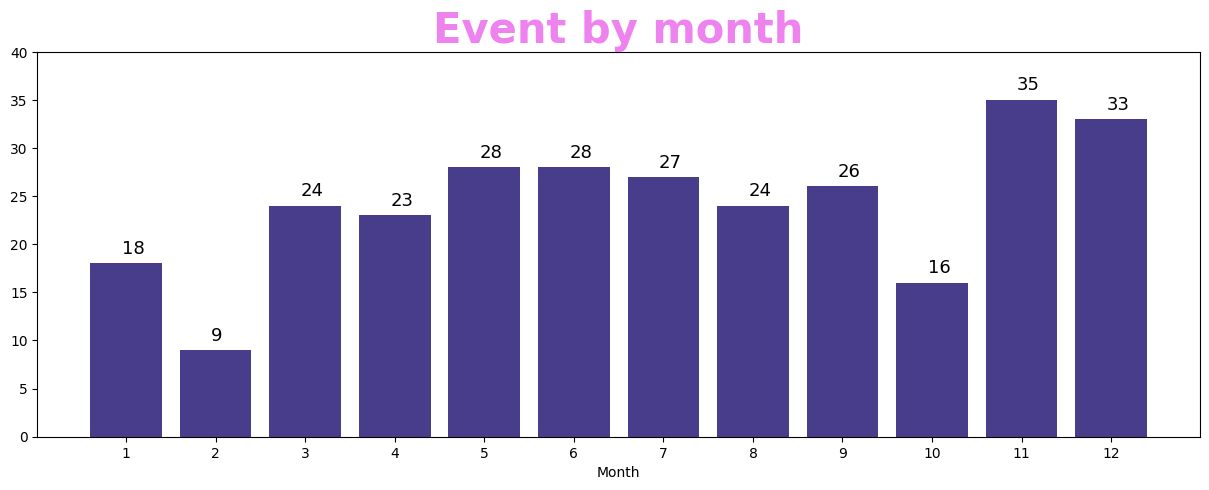

In [49]:
plt.figure(figsize = (15,5))
plt.bar(height = vc.values, x = vc.index, color = "darkslateblue")
plt.xticks(vc.index, vc.index)
for i in vc.index:
  plt.annotate(vc[i], xy = (i-0.05, vc[i]+1), size = 13)
plt.ylim(0, 5 * round(vc.max()/5) +5)
plt.xlabel("Month")
plt.title("Event by month", size = 30, color = "violet",weight = "heavy")
plt.show()

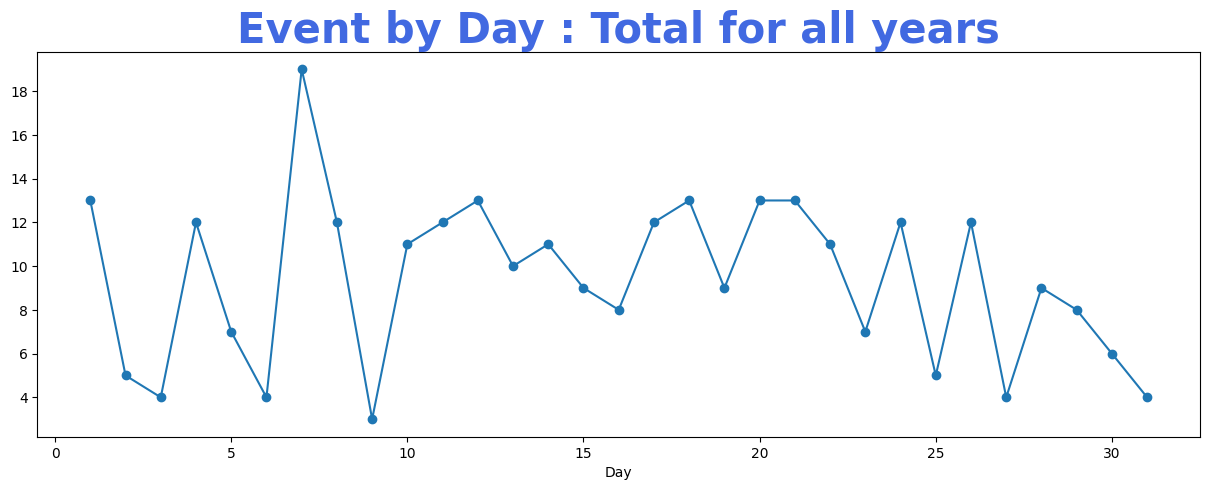

In [50]:
vc = data.event_day.value_counts()
vc = vc.sort_index()
plt.figure(figsize = (15,5))
plt.plot( vc.index, vc.values)
plt.scatter( vc.index, vc.values)
plt.xlabel("Day")
plt.title("Event by Day : Total for all years", size = 30, color = "royalblue",weight = "heavy")
plt.show()

Conclusion : Tesla's accident volume tends to increase every year The number of accidents in November and December is the highest.

Day wise no concrete info as the distribution pattern is irregular However for year wise pattern we should be considering the accidents vs sales data.

More Tesla on road will definetly bring a rise in no. of accidents while proportion of accidents might not increase as such.

In [51]:
vc= data.Country.value_counts()
vc

,count
Country,
USA,213
China,16
Germany,11
Canada,9
Netherlands,6
UK,5
Norway,4
Holland,3
Switzerland,3


/tmp/ipykernel_2009/1218244808.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.annotate(vc[i], xy = (i-0.1, vc[i]+2), size = 10)


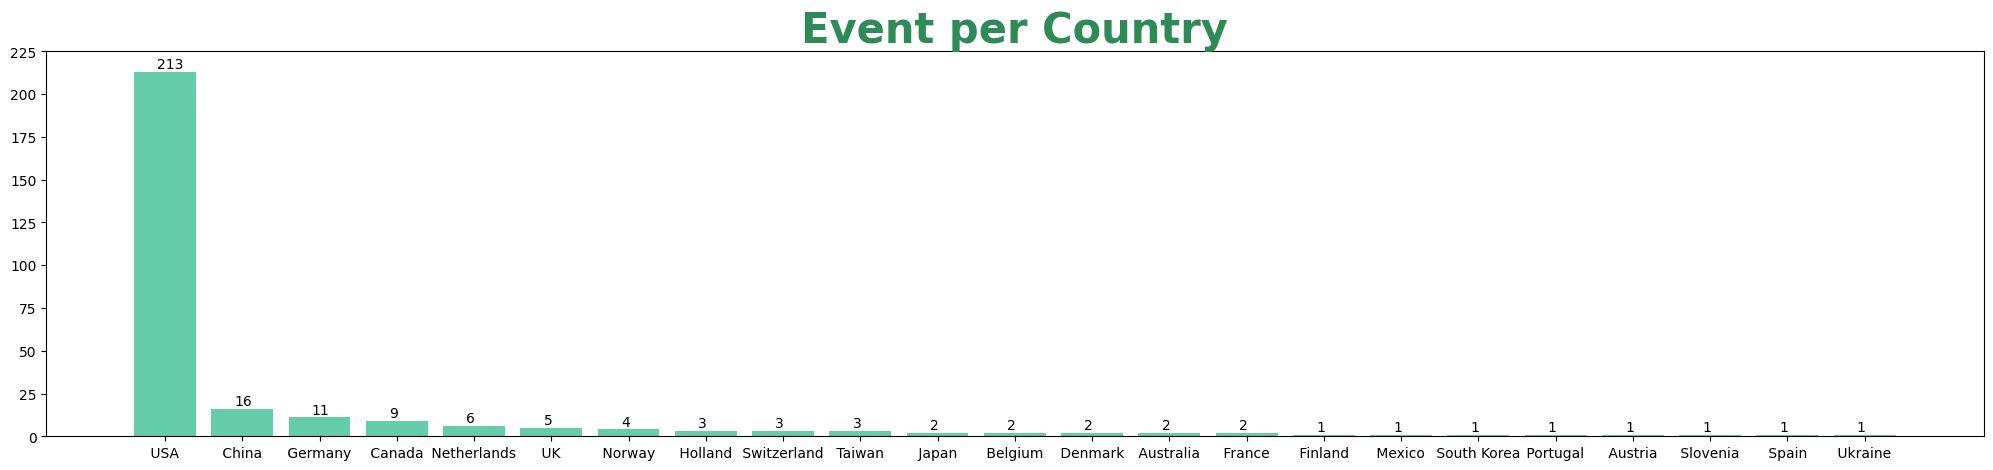

In [52]:
vc = data.Country.value_counts()
plt.figure(figsize = (25,5))
plt.bar(height = vc.values, x = vc.index, color = "mediumaquamarine")
plt.xticks(vc.index, vc.index)
for i in range(len(vc.index)):
  plt.annotate(vc[i], xy = (i-0.1, vc[i]+2), size = 10)
plt.title("Event per Country", size = 30, color = "seagreen", weight = "heavy")
plt.ylim(0, 25 * round(vc.max()/25))
plt.show()

In [53]:
data['State'].value_counts()

,count
State,
-,78
CA,75
FL,24
CA,15
FL,8
AZ,8
OH,6
GA,6
NY,5


In [54]:
vc = data.State.value_counts()

In [55]:
vc = data.State.value_counts()
vc = vc[vc.index!='-']

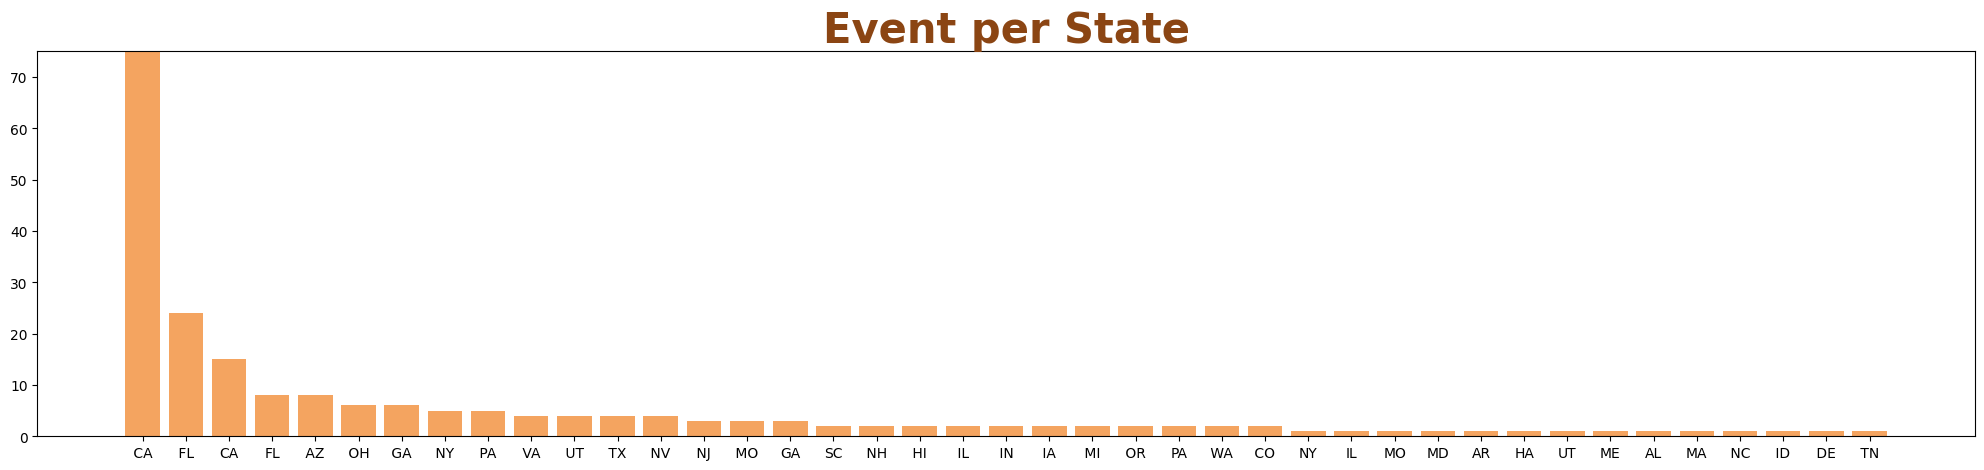

In [56]:

plt.figure(figsize = (25,5))
plt.bar(height = vc.values, x = vc.index, color = "sandybrown")
plt.xticks(vc.index, vc.index)
plt.title("Event per State", size = 30, color = "saddlebrown", weight = "heavy")
plt.ylim(0, 25 * round(vc.max()/25))
plt.show()

In [65]:
data.State.unique()

array(['GA', '-', 'CA', 'MO', 'AR', 'IL', 'FL', 'SC', 'MD', 'NY', 'MA',
       'ME', 'UT', 'PA', 'HA', 'AL', ' MI ', ' CA ', ' NV ', ' NY ',
       ' OR ', ' AZ ', ' NJ ', ' CO ', ' UT ', ' PA ', ' NC ', ' FL ',
       ' ID ', ' MO ', ' OH ', ' GA ', ' IA ', ' WA ', ' VA ', ' TX ',
       ' IL ', ' IN ', ' DE ', ' NH ', ' TN ', ' HI '], dtype=object)

In [66]:
data.State=data.State.str.strip()

/tmp/ipykernel_2009/461575304.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.State=data.State.str.strip()


In [67]:
data.State.unique()

array(['GA', '-', 'CA', 'MO', 'AR', 'IL', 'FL', 'SC', 'MD', 'NY', 'MA',
       'ME', 'UT', 'PA', 'HA', 'AL', 'MI', 'NV', 'OR', 'AZ', 'NJ', 'CO',
       'NC', 'ID', 'OH', 'IA', 'WA', 'VA', 'TX', 'IN', 'DE', 'NH', 'TN',
       'HI'], dtype=object)

In [68]:
vc = data.State.value_counts()
vc = vc[vc.index != "-"]

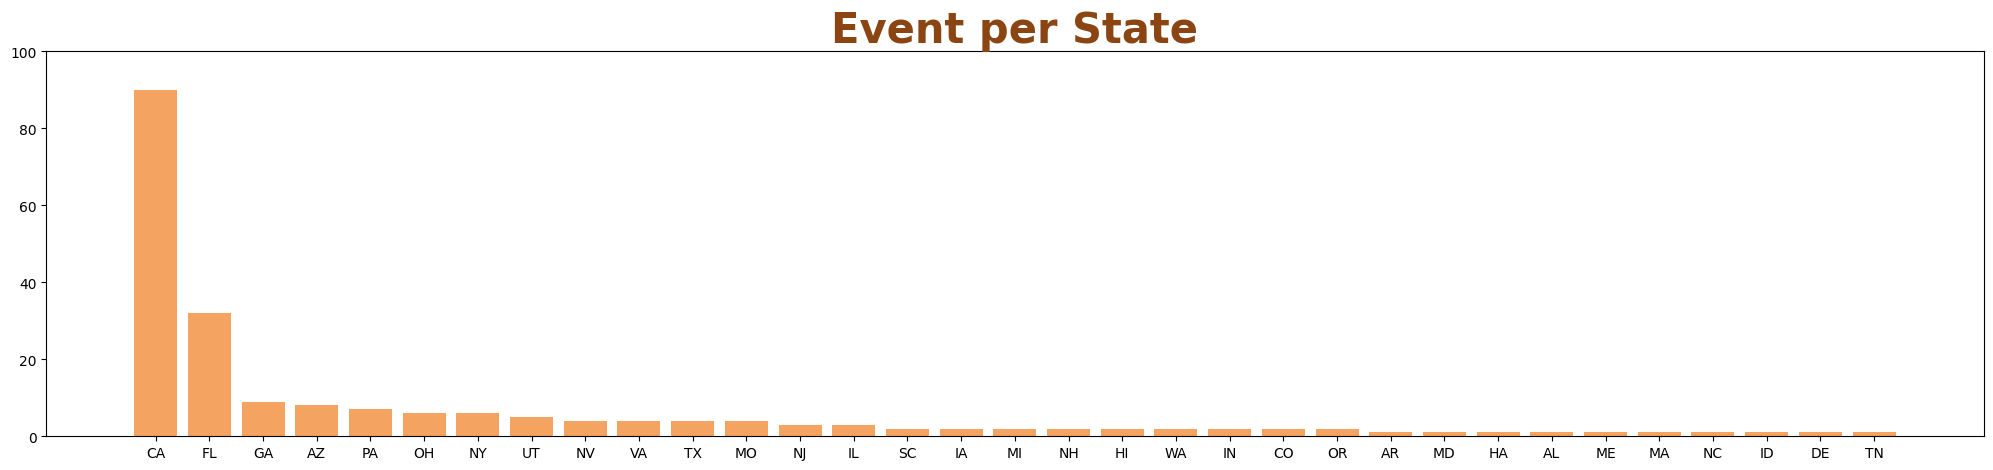

In [69]:
plt.figure(figsize = (25,5))
plt.bar(height = vc.values, x = vc.index, color = "sandybrown")
plt.xticks(vc.index, vc.index)
plt.title("Event per State", size = 30, color = "saddlebrown", weight = "heavy")
plt.ylim(0, 25 * round(vc.max()/25))
plt.show()

Analyze the different aspects of the death events. For example:
What is the number of victims (deaths) in each accident?
How many times did tesla drivers die?
What is the proportion of events in which one or more occupants died?
What is the distribution of events in which the vehicle hit a cyclist or a pedestrian?
How many times did the accident involve the death of an occupant or driver of a Tesla along with a cyclist or pedestrian?
What is the frequency of Tesla colliding with other vehicles?

In [70]:
data.columns

Index(['Date', 'Country', 'State', 'Description', 'Deaths', 'Tesla_Driver',
       'Tesla_Occupant', 'Other_Vehicle', 'Cyclists_Peds', 'TSLA_cycl_peds',
       'Model', 'Claimed', 'VTAD', 'event_year', 'event_month', 'event_day'],
      dtype='object')

In [71]:
col_list = ['Deaths', 'Tesla_Driver','Tesla_Occupant', 'Other_Vehicle', 'Cyclists_Peds', 'TSLA_cycl_peds']

In [72]:
colr = ['salmon', 'mediumaquamarine', 'mediumpurple', 'goldenrod', 'silver', 'saddlebrown']

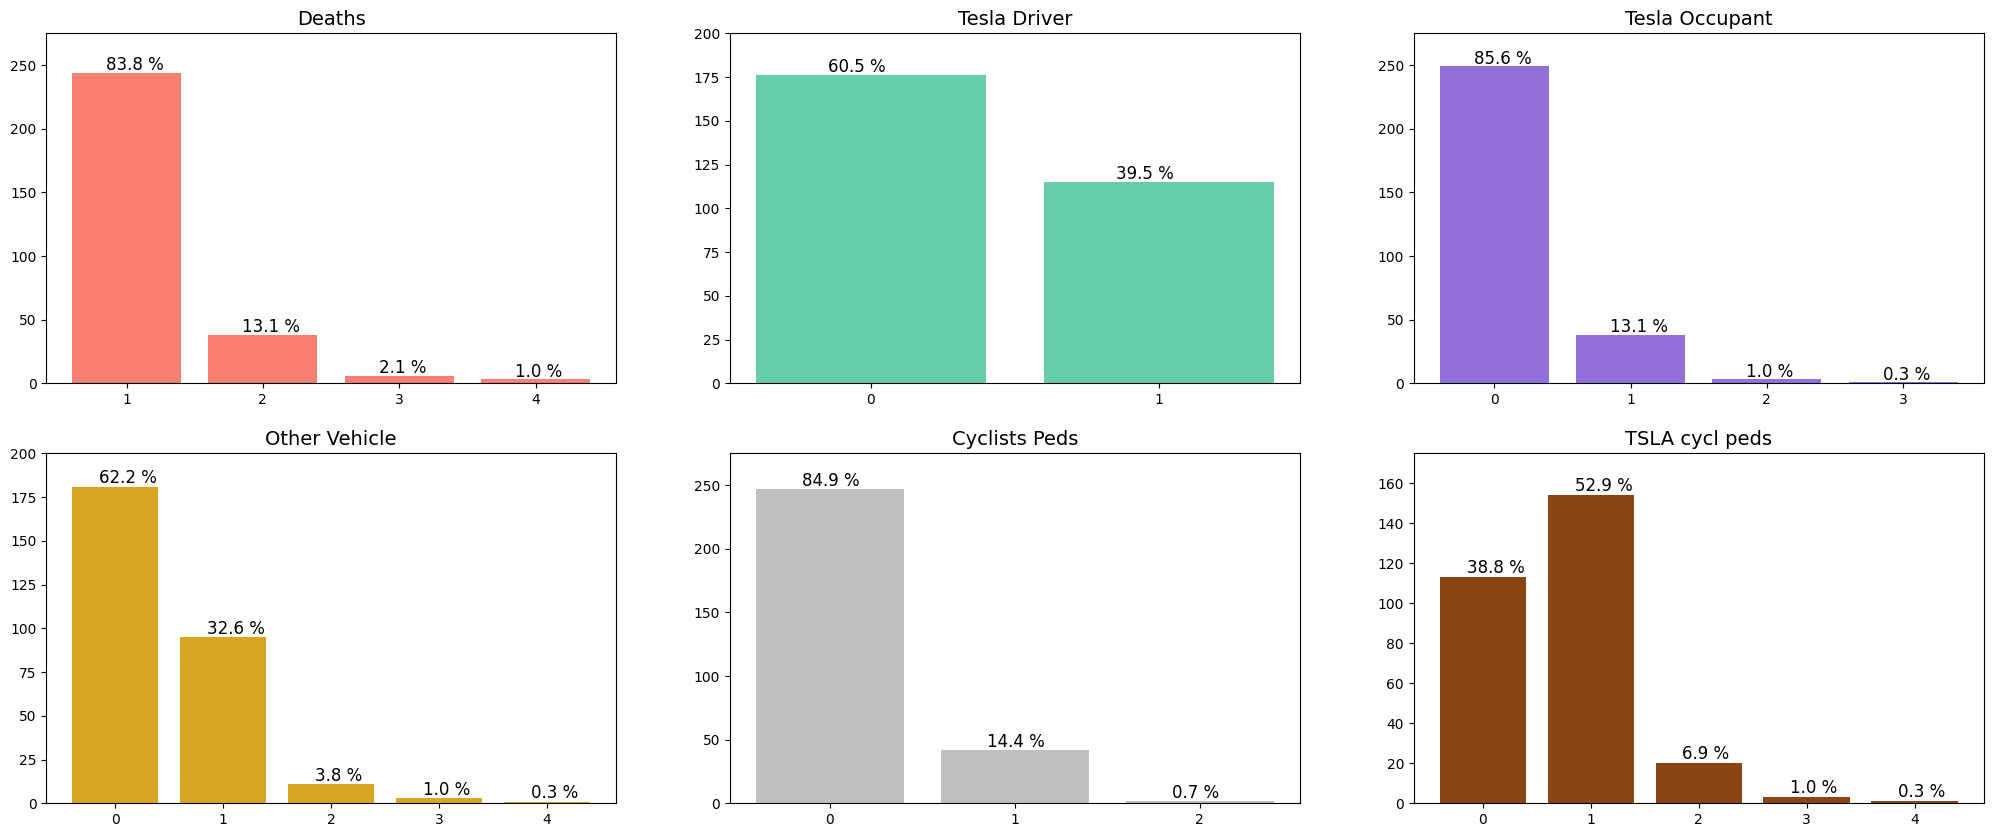

In [73]:
f,ax = plt.subplots(2,3, figsize = (25,10))
i,j,k = 0,0,0
for col in col_list:
  vc = data[col].value_counts()
  vc = vc.sort_index()
  perc = (vc/vc.sum()*100).round(1)
  #print(vc)
  ax[i,j].bar(x = vc.index, height = vc.values, color = colr[k])
  ax[i,j].set_title(col.replace("_", " "), size = 14)
  ax[i,j].set_xticks(vc.index)
  for l in vc.index:
    #print(l)
    ax[i,j].annotate("{} %".format(perc[l]), xy = (l-0.15,vc[l]+2), size = 12)
    ax[i,j].set_ylim(0,  25 * round(vc.max()/25)+25)
  j += 1
  k += 1
  if j == 3:
    j = 0
    i += 1

# study the event distribution across columns

In [75]:
data['Model'].value_counts()

,count
Model,
-,178
S,45
3,39
X,17
Y,10
1,1
2,1


In [76]:
data.Model = data.Model.str.strip()
data.Model = data.Model.replace("-", "0")

/tmp/ipykernel_2009/4213050478.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.Model = data.Model.str.strip()
/tmp/ipykernel_2009/4213050478.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.Model = data.Model.replace("-", "0")


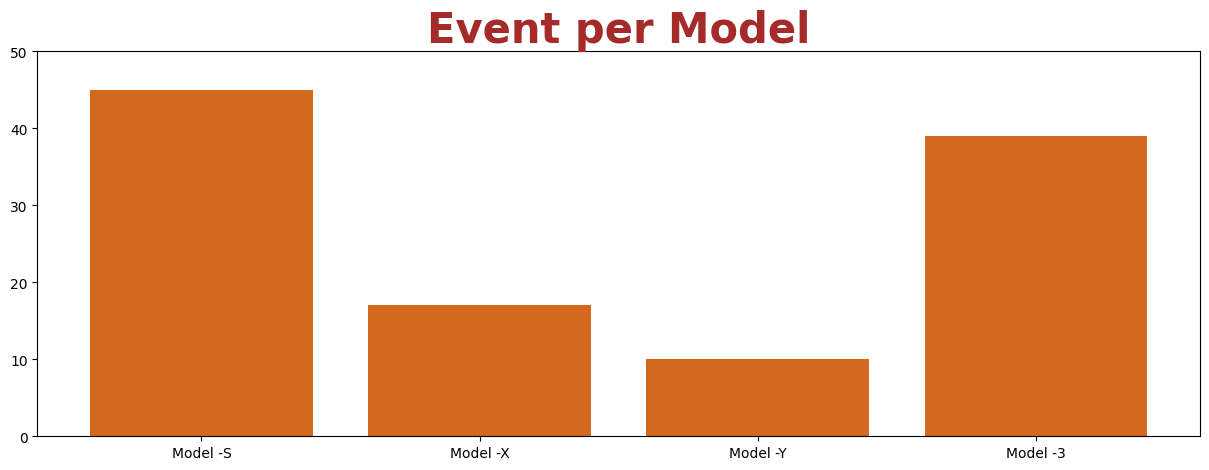

In [77]:
vc = data.Model.value_counts()
vc = vc[["S", "X", "Y", "3"]]
plt.figure(figsize = (15,5))
plt.bar(height = vc.values, x = vc.index, color = "chocolate")
plt.xticks(vc.index, "Model -"+ vc.index.astype(str))
plt.title("Event per Model", size = 30, color = "brown", weight = "heavy")
plt.ylim(0, 25 * round(vc.max()/25))
plt.show()

Check the distribution of Verified Tesla autopilot deaths.

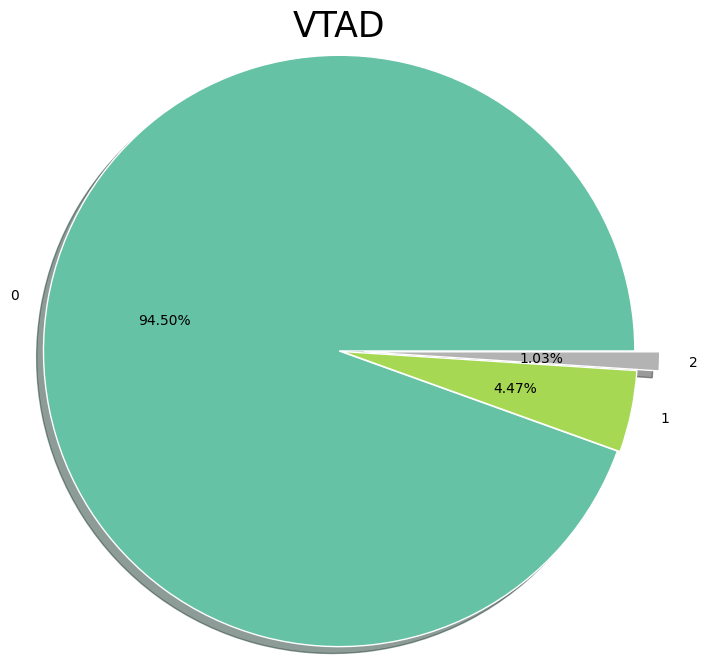

In [78]:
vc = data.VTAD.value_counts()
plt.figure(figsize = (10,8))
vc.plot.pie(radius = 1.2, autopct = "%1.2f%%", shadow = True, wedgeprops = {'edgecolor':"white"}, cmap = 'Set2',
            explode = [0.001, 0.01,0.1])
plt.ylabel("")
plt.title("VTAD", pad = 5, size = 25)
plt.show()